# Baseline Supervised Training — Prediction Track

This notebook assembles a clean supervised training pipeline for the competition track. It converts the raw `train/input_*.csv` & `train/output_*.csv` files into normalized tensors, trains a lightweight physics-aware seq2seq model, and exports checkpoints + metadata that can be uploaded to Kaggle as a dataset for inference notebooks. Pre-training hooks are left out on purpose so we can get a solid supervised baseline first.

## 1. Environment bootstrap
We locate the `prediction/src` package (so the notebook works both locally and on Kaggle) and set up a helper that finds either an extracted dataset directory or the provided zip archive.

In [1]:
import json
import os
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler

PROJECT_ROOT = Path.cwd().resolve()


def _gather_src_candidates(base: Path) -> list[Path]:
    rel_paths = (
        'src',
        'prediction/src',
        'workspace/prediction/src',
    )
    out = []
    for rel in rel_paths:
        out.append((base / rel).resolve())
    return out


def resolve_src_dir() -> Path:
    candidates = []
    seen = set()

    def add(path: Path):
        path = Path(path)
        try:
            path = path.resolve()
        except Exception:
            pass
        if path in seen:
            return
        seen.add(path)
        candidates.append(path)

    env_src = os.getenv('BDB2026_SRC')
    if env_src:
        add(Path(env_src))

    search_roots = [PROJECT_ROOT] + list(PROJECT_ROOT.parents[:5])
    for root in search_roots:
        for cand in _gather_src_candidates(root):
            add(cand)

    kaggle_work = Path('/kaggle/working')
    if kaggle_work.exists():
        for cand in _gather_src_candidates(kaggle_work):
            add(cand)

    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        for child in kaggle_input.iterdir():
            cand = child / 'src'
            add(cand)
            cand_pred = child / 'prediction' / 'src'
            add(cand_pred)

    for cand in candidates:
        if cand.exists():
            path_str = str(cand)
            if path_str not in sys.path:
                sys.path.append(path_str)
            return cand

    raise FileNotFoundError(
        'Could not locate prediction/src directory. Set BDB2026_SRC or mount the repo next to this notebook.'
    )


SRC_DIR = resolve_src_dir()
print('Using src dir:', SRC_DIR)

Using src dir: C:\Users\16476\big_data_bowl\prediction\src


## 2. Configuration
Define data/model/optim hyper-parameters. Feel free to tweak the splits or batch sizes depending on the Kaggle accelerator you select.

In [2]:
from dataclasses import asdict

from bdb2026.config import DataConfig, ModelConfig, OptimConfig, ExperimentConfig
from bdb2026.data import CompetitionData, build_sample_records, save_vocabulary
from bdb2026.dataset import TrajectoryDataset, collate_fn, filter_by_week
from bdb2026.model import TrajectoryModel
from bdb2026.train import run_epoch, save_checkpoint, seed_everything

seed_everything(2026)

data_config = DataConfig(
    encoder_frames=12,
    decoder_frames=32,
    train_weeks=(1, 15),
    val_weeks=(15, 19),
)
model_config = ModelConfig(
    hidden_size=256,
    encoder_layers=1,
    decoder_layers=1,
    dropout=0.05,
    teacher_forcing=0.2,
    delta_weight=0.1,
)
model_config.decoder_steps = data_config.decoder_frames
optim_config = OptimConfig(
    batch_size=256,
    val_batch_size=384,
    num_workers=2,
    learning_rate=5e-4,
    weight_decay=1e-2,
    max_epochs=10,
    grad_clip=1.0,
    device='cuda',
    ema_decay=0.995,
)
config = ExperimentConfig(data=data_config, model=model_config, optim=optim_config)

CHECKPOINT_DIR = Path(os.getenv('BDB2026_CHECKPOINT_DIR', PROJECT_ROOT / '../outputs/prediction/checkpoints')).resolve()
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
print('Artifacts will be written to', CHECKPOINT_DIR)


Artifacts will be written to C:\Users\16476\big_data_bowl\prediction\outputs\prediction\checkpoints


## 3. Build train/validation tensors
This step loads every `train/input_*.csv` + `train/output_*.csv`, normalizes the coordinates, and stores per-target samples. Set `LIMIT_TRAIN_SAMPLES` if you want a very quick debug run.

In [3]:
LIMIT_TRAIN_SAMPLES = None  # e.g. 2000 for a smoke-test

import os
from pathlib import Path

if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path.cwd().resolve()


def _maybe_path(value):
    if not value:
        return None
    return Path(value).expanduser()


def _ensure_data_source():
    global DATA_ROOT, DATA_ZIP
    if 'DATA_ROOT' in globals() and 'DATA_ZIP' in globals():
        if DATA_ROOT is not None or DATA_ZIP is not None:
            return

    data_candidates = [
        _maybe_path(os.getenv('BDB2026_DATA')),
        Path('/kaggle/input/nfl-big-data-bowl-2026'),
        PROJECT_ROOT / '../input/nfl-big-data-bowl-2026',
        PROJECT_ROOT / '../../input/nfl-big-data-bowl-2026',
    ]
    for cand in data_candidates:
        if cand and cand.exists():
            DATA_ROOT = cand.resolve()
            DATA_ZIP = None
            return

    zip_candidates = [
        _maybe_path(os.getenv('BDB2026_ZIP')),
        PROJECT_ROOT / '../nfl-big-data-bowl-2026-prediction.zip',
        PROJECT_ROOT / '../../nfl-big-data-bowl-2026-prediction.zip',
        PROJECT_ROOT / 'nfl-big-data-bowl-2026-prediction.zip',
    ]
    for cand in zip_candidates:
        if cand and cand.exists():
            DATA_ROOT = None
            DATA_ZIP = cand.resolve()
            return

    raise FileNotFoundError('Could not locate data directory or zip archive. Run the bootstrap cell or set BDB2026_DATA/BDB2026_ZIP.')


_ensure_data_source()

competition_data = CompetitionData(data_root=DATA_ROOT, zip_path=DATA_ZIP)
samples, vocab = build_sample_records(
    competition_data,
    encoder_frames=config.data.encoder_frames,
    decoder_frames=config.data.decoder_frames,
)
print(f'Loaded {len(samples):,} target samples across all weeks.')

train_samples = filter_by_week(samples, config.data.train_weeks)
val_samples = filter_by_week(samples, config.data.val_weeks)
if LIMIT_TRAIN_SAMPLES:
    train_samples = train_samples[:LIMIT_TRAIN_SAMPLES]

print(f'Train samples: {len(train_samples):,} | Val samples: {len(val_samples):,}')

summary = pd.DataFrame([
    {
        'game_id': rec.ids[0],
        'play_id': rec.ids[1],
        'nfl_id': rec.ids[2],
        'week': rec.week,
        'horizon': rec.num_frames_output,
    }
    for rec in train_samples[:5000]
])
if not summary.empty:
    display(summary.groupby('week').agg({'game_id':'nunique','horizon':'mean'}).rename(columns={'game_id':'plays'}))


Loaded 46,045 target samples across all weeks.
Train samples: 35,467 | Val samples: 10,578


,plays,horizon
week,,
1,16,11.977604
2,14,11.614821


## 4. Dataloaders + model init

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
config.optim.device = str(device)

train_ds = TrajectoryDataset(train_samples, augment=True)
val_ds = TrajectoryDataset(val_samples, augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=config.optim.batch_size,
    shuffle=True,
    drop_last=False,
    num_workers=config.optim.num_workers,
    pin_memory=device.type == 'cuda',
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_ds,
    batch_size=config.optim.val_batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=config.optim.num_workers,
    pin_memory=device.type == 'cuda',
    collate_fn=collate_fn,
)

feature_dim = train_samples[0].context_features.shape[-1]
static_dim = train_samples[0].static_features.shape[-1]
config.model.feature_dim = feature_dim
config.model.static_dim = static_dim
config.model.decoder_steps = config.data.decoder_frames

vocab_sizes = {name: len(v) for name, v in vocab.items()}
model = TrajectoryModel(config.model, feature_dim, static_dim, vocab_sizes).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.optim.learning_rate, weight_decay=config.optim.weight_decay)
scaler = GradScaler(enabled=device.type == 'cuda')


C:\Users\16476\AppData\Local\Temp\ipykernel_3848\4241492993.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=device.type == 'cuda')


## 5. Training loop
Logs ADE/FDE each epoch and keeps the best checkpoint, vocab, and config JSON so inference notebooks can stay in sync.

In [5]:
history = []
best_val = float('inf')
checkpoint_path = CHECKPOINT_DIR / 'prgt_baseline.pt'
vocab_path = CHECKPOINT_DIR / 'vocab.json'
config_path = CHECKPOINT_DIR / 'config.json'
ema_decay = getattr(config.optim, 'ema_decay', 0.0)
ema_model = None
if ema_decay and ema_decay > 0:
    ema_model = TrajectoryModel(config.model, feature_dim, static_dim, vocab_sizes).to(device)
    ema_model.load_state_dict(model.state_dict())
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.optim.max_epochs,
    eta_min=config.optim.learning_rate * 0.1,
)

for epoch in range(1, config.optim.max_epochs + 1):
    progress = (epoch - 1) / config.optim.max_epochs
    teacher_forcing = max(0.05, config.model.teacher_forcing * (1 - progress))
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}: lr {current_lr:.6f} | teacher forcing {teacher_forcing:.4f}")
    train_stats = run_epoch(
        model,
        train_loader,
        optimizer,
        scaler,
        config.optim,
        train=True,
        teacher_forcing=teacher_forcing,
        delta_weight=config.model.delta_weight,
        ema_model=ema_model,
        ema_decay=ema_decay,
    )
    eval_model = ema_model if ema_model is not None else model
    val_stats = run_epoch(
        eval_model,
        val_loader,
        optimizer,
        scaler,
        config.optim,
        train=False,
        teacher_forcing=0.0,
        delta_weight=config.model.delta_weight,
    )
    stats = {
        'epoch': epoch,
        'train_loss': train_stats['loss'],
        'train_ade': train_stats['ade'],
        'train_fde': train_stats['fde'],
        'val_loss': val_stats['loss'],
        'val_ade': val_stats['ade'],
        'val_fde': val_stats['fde'],
    }
    history.append(stats)
    print(f"  train ADE {stats['train_ade']:.4f} | val ADE {stats['val_ade']:.4f}")
    if val_stats['ade'] < best_val:
        best_val = val_stats['ade']
        best_model = eval_model if ema_model is not None else model
        save_checkpoint(best_model, optimizer, scaler, epoch, checkpoint_path)
        save_vocabulary(vocab, vocab_path)
        config_path.write_text(json.dumps(config.to_dict(), indent=2))
        print('  Saved new best checkpoint.')
    scheduler.step()

history_df = pd.DataFrame(history)
history_df.to_csv(CHECKPOINT_DIR / 'training_history.csv', index=False)
history_df


Epoch 1: lr 0.000500 | teacher forcing 0.2000


  train ADE 0.1802 | val ADE 0.2587
  Saved new best checkpoint.
Epoch 2: lr 0.000489 | teacher forcing 0.1800


  train ADE 0.1286 | val ADE 0.1449
  Saved new best checkpoint.
Epoch 3: lr 0.000457 | teacher forcing 0.1600


  train ADE 0.0694 | val ADE 0.0709
  Saved new best checkpoint.
Epoch 4: lr 0.000407 | teacher forcing 0.1400


  train ADE 0.0569 | val ADE 0.0396
  Saved new best checkpoint.
Epoch 5: lr 0.000345 | teacher forcing 0.1200


...

  train ADE 0.0492 | val ADE 0.0283
  Saved new best checkpoint.
Epoch 8: lr 0.000143 | teacher forcing 0.0600


  train ADE 0.0537 | val ADE 0.0273
  Saved new best checkpoint.
Epoch 9: lr 0.000093 | teacher forcing 0.0500


  train ADE 0.0356 | val ADE 0.0260
  Saved new best checkpoint.
Epoch 10: lr 0.000061 | teacher forcing 0.0500


  train ADE 0.0250 | val ADE 0.0247
  Saved new best checkpoint.


,epoch,train_loss,train_ade,train_fde,val_loss,val_ade,val_fde
0,1,-0.362604,0.180223,0.228541,-0.116475,0.258671,0.415245
1,2,-0.551099,0.128584,0.156663,-0.448955,0.144884,0.225733
2,3,-0.589957,0.069369,0.088957,-0.571474,0.070859,0.109505
3,4,-0.593464,0.056925,0.074259,-0.594258,0.039612,0.064727
4,5,-0.594108,0.055141,0.073808,-0.597916,0.031592,0.055114
5,6,-0.596497,0.041179,0.057310,-0.598426,0.029255,0.052442
6,7,-0.594696,0.049169,0.068553,-0.598514,0.028279,0.050965
7,8,-0.594850,0.053651,0.075226,-0.598592,0.027288,0.049660
8,9,-0.597670,0.035646,0.053416,-0.598693,0.026045,0.047761
9,10,-0.598732,0.025025,0.041267,-0.598800,0.024701,0.045415


## 6. Quick sanity visualization
Plot a random validation trajectory vs. the ground truth to verify scale/orientation.

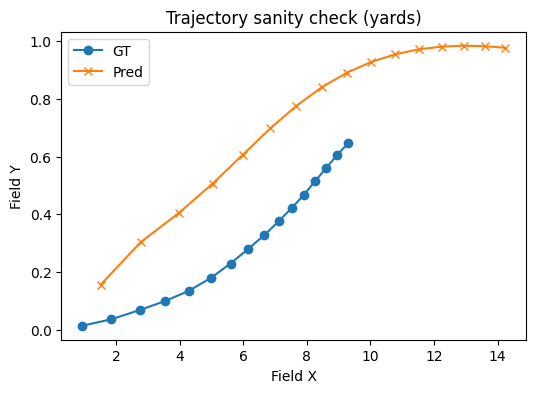

In [6]:
import matplotlib.pyplot as plt
from bdb2026.train import move_to_device

model.eval()
with torch.no_grad():
    sample_batch = next(iter(val_loader))
    sample_batch = move_to_device(sample_batch, device)
    preds, _, _ = model(sample_batch, teacher_forcing=0.0)
    preds = preds.cpu().numpy()
    targets = sample_batch['target_positions'].cpu().numpy()

idx = np.random.randint(0, preds.shape[0])
pred_seq = preds[idx]
target_seq = targets[idx]
mask = sample_batch['target_mask'][idx].cpu().numpy().astype(bool)

plt.figure(figsize=(6, 4))
plt.plot(target_seq[mask, 0] * 120, target_seq[mask, 1] * 53.3, label='GT', marker='o')
plt.plot(pred_seq[mask, 0] * 120, pred_seq[mask, 1] * 53.3, label='Pred', marker='x')
plt.title('Trajectory sanity check (yards)')
plt.xlabel('Field X')
plt.ylabel('Field Y')
plt.legend()
plt.show()


## 7. Export notes
- Upload everything inside `outputs/prediction/checkpoints/` (weights, `config.json`, `vocab.json`, optional history CSV) as a Kaggle Dataset when you like your model.
- On Kaggle, set that dataset as an input to the inference notebook plus the official competition dataset.
- If VRAM is tight, lower `hidden_size`, `batch_size`, or restrict `train_weeks`.
- Extend this notebook with additional augmentations or alternative heads once the baseline is stable.